<h5>Import and clean data</h5>

In [1]:
import json
import pandas as pd
from src.normalization import get_normalized_list
from src.clean_data import clean_data

with open("data.json") as f:
    raw_data = json.load(f)

data = clean_data(raw_data)


# companies = pd.DataFrame(data["companies"])
# schools = pd.DataFrame(data["schools"])

normalized_companies = get_normalized_list(data["companies"])
normalized_schools = get_normalized_list(data["schools"])

# Add normalized company names to experiences
for experience in data["experiences"]:
    if experience["company"] is None:
        continue
    normalized_name = normalized_companies.get(experience["company"], experience["company"])
    experience["normalized_company"] = normalized_name

# Add normalized school names to educations
for education in data["educations"]:
    if education["school"] is None:
        continue
    normalized_name = normalized_schools.get(education["school"], education["school"])
    education["normalized_school"] = normalized_name

<h5>Top companies and schools</h5>

In [5]:
experiences_df = pd.DataFrame(data["experiences"])
educations_df = pd.DataFrame(data["educations"])

# What are the companies with the biggest amount of unique people
top_companies = (
    experiences_df
    .groupby("normalized_company")["person_id"]
    # .groupby("company")["person_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

# What are the schools with the biggest amount of unique people
top_schools = (
    educations_df
    .groupby("normalized_school")["person_id"]
    # .groupby("school")["person_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(2)
)

print(top_companies)
# print(top_schools)

normalized_company
Clemson University           89
Social Slooth                16
Invisible Technologies        9
Ascendancy                    7
Amazon                        6
LPL Financial                 5
Accenture                     5
Michigan State University     4
Prisma Health                 4
Google                        4
Name: person_id, dtype: int64


<h5>Graph</h5>

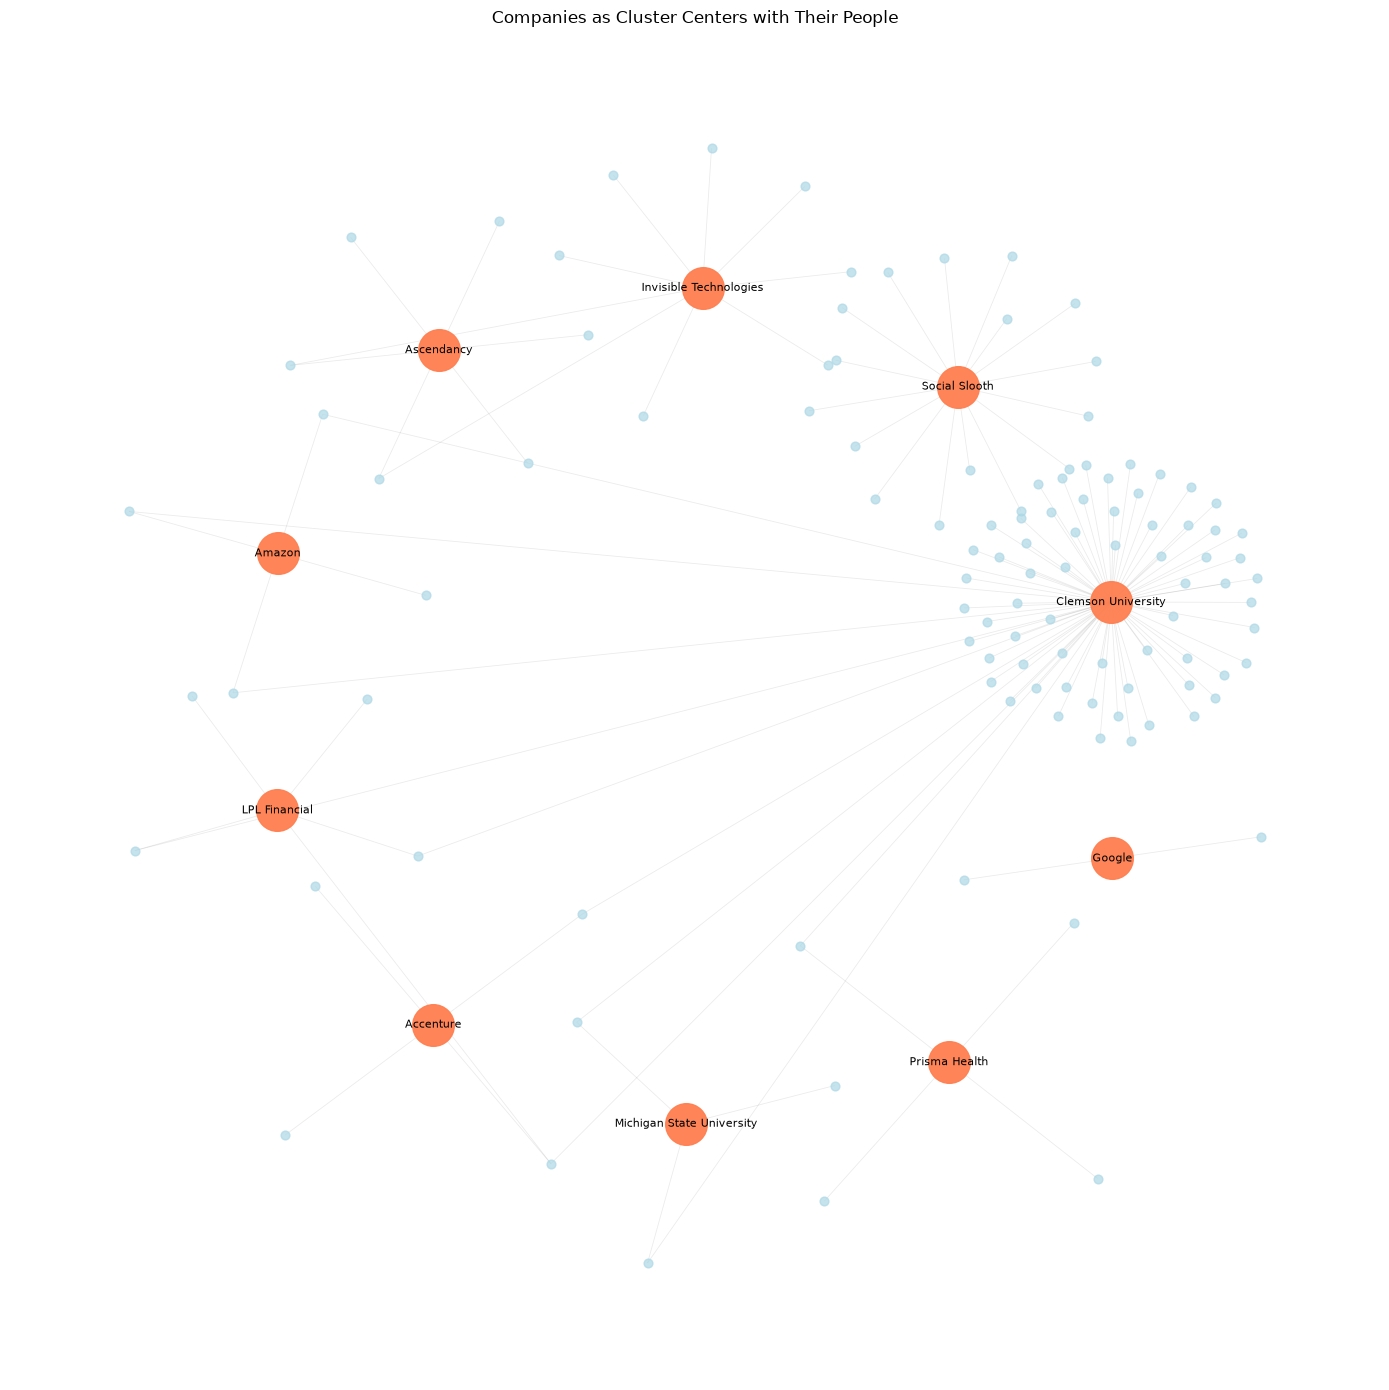

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Build bipartite graph from filtered experiences
filtered_df = experiences_df[experiences_df["company"].isin(top_companies.index)]
G = nx.Graph()
for _, row in filtered_df.iterrows():
    G.add_node(row["person_id"], type="person")
    G.add_node(row["normalized_company"], type="company")
    G.add_edge(row["person_id"], row["normalized_company"])

# Companies are the cluster "supernodes"
companies = list(top_companies.index)

# Create a supergraph (one node per company) to compute well-spaced centers
supergraph = nx.cycle_graph(len(companies))
superpos = nx.spring_layout(supergraph, scale=3, seed=42)
centers = list(superpos.values())

# For each company, compute a local layout for the company + its people
pos = {}
for center, company in zip(centers, companies):
    members = [company] + list(G.neighbors(company))
    if len(members) == 1:
        # company with no people — place at center
        pos[company] = tuple(center)
        continue
    subpos = nx.spring_layout(G.subgraph(members), center=center, seed=123)
    # Ensure the company stays at the exact center
    subpos[company] = tuple(center)
    pos.update(subpos)

# Draw
plt.figure(figsize=(14, 14))
nx.draw_networkx_edges(G, pos, alpha=0.08, width=0.6)

# People nodes: all nodes that are not company labels
people = [n for n in G.nodes() if n not in companies]
nx.draw_networkx_nodes(G, pos, nodelist=people, node_size=40, node_color="lightblue", alpha=0.7)

# Company nodes: larger and labeled
nx.draw_networkx_nodes(G, pos, nodelist=companies, node_size=900, node_color="coral", alpha=0.95)
nx.draw_networkx_labels(G, pos, labels={c: c for c in companies}, font_size=8)

plt.title("Companies as Cluster Centers with Their People")
plt.axis("off")
plt.tight_layout()
plt.show()

<h5>People Metrics</h5>

In [24]:
import pprint

person_names = (
  pd.DataFrame(data["people"])
  [["person_id", "full_name"]]
)

person_degrees = {
    n: d for n, d in G.degree()
    if G.nodes[n]["type"] == "person"
}

# print(
#   pd.DataFrame.from_dict(person_degrees, orient="index", columns=["degree"])
#   .rename_axis("person_id")
#   .reset_index()
#   .merge(person_names, on="person_id", how="left")
#   .sort_values(by="degree", ascending=False)
#   [["full_name", "degree"]]
#   .head(10)
# )

person_degree_centrality = {
    n: d for n, d in nx.degree_centrality(G).items()
    if G.nodes[n]["type"] == "person"
}

# print(
#   pd.DataFrame.from_dict(person_degree_centrality, orient="index", columns=["degree_centrality"])
#   .rename_axis("person_id")
#   .reset_index()
#   .merge(person_names, on="person_id", how="left")
#   .sort_values(by="degree_centrality", ascending=False)
#   [["full_name", "degree_centrality"]]
#   .head(10)
# )

person_betweenness = {
    n: d for n, d in nx.betweenness_centrality(G).items()
    if G.nodes[n]["type"] == "person"
}   

# print(
#   pd.DataFrame.from_dict(person_betweenness, orient="index", columns=["betweenness_centrality"])
#   .rename_axis("person_id")
#   .reset_index()
#   .merge(person_names, on="person_id", how="left")
#   .sort_values(by="betweenness_centrality", ascending=False)
#   [["full_name", "betweenness_centrality"]]
#   .head(10)
# )

person_eigenvector = {
    n: d for n, d in nx.eigenvector_centrality(G).items()
    if G.nodes[n]["type"] == "person"
}   

# print(
#   pd.DataFrame.from_dict(person_eigenvector, orient="index", columns=["eigenvector_centrality"])
#   .rename_axis("person_id")
#   .reset_index()
#   .merge(person_names, on="person_id", how="left")
#   .sort_values(by="eigenvector_centrality", ascending=False)
#   [["full_name", "eigenvector_centrality"]]
#   .head(10)
# )



<h5>Company Metrics</h5>

In [22]:
company_degrees = {
    n: d for n, d in G.degree()
    if G.nodes[n]["type"] == "company"
}

# print(
#   pd.DataFrame.from_dict(company_degrees, orient="index", columns=["degree"])
#   .rename_axis("company")
#   .reset_index()
#   .sort_values(by="degree", ascending=False)
#   [["company", "degree"]]
#   .head(10)
# )


company_degree_centrality = {
    n: d for n, d in nx.degree_centrality(G).items()
    if G.nodes[n]["type"] == "company"
}

# print(
#   pd.DataFrame.from_dict(company_degree_centrality, orient="index", columns=["degree_centrality"])
#   .rename_axis("company")
#   .reset_index()
#   .sort_values(by="degree_centrality", ascending=False)
#   [["company", "degree_centrality"]]
#   .head(10)
# )

company_betweenness = {
    n: d for n, d in nx.betweenness_centrality(G).items()
    if G.nodes[n]["type"] == "company"
}

# print(
#   pd.DataFrame.from_dict(company_betweenness, orient="index", columns=["betweenness_centrality"])
#   .rename_axis("company")
#   .reset_index()
#   .sort_values(by="betweenness_centrality", ascending=False)
#   [["company", "betweenness_centrality"]]
#   .head(10)
# )

company_eigenvector = {
    n: d for n, d in nx.eigenvector_centrality(G).items()
    if G.nodes[n]["type"] == "company"
}

# print(
#   pd.DataFrame.from_dict(company_eigenvector, orient="index", columns=["eigenvector_centrality"])
#   .rename_axis("company")
#   .reset_index()
#   .sort_values(by="eigenvector_centrality", ascending=False)
#   [["company", "eigenvector_centrality"]]
#   .head(10)
# )

<h5>Density</h5>

In [27]:
density = nx.density(G)
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
print(f"Graph density: {density:.4f}")

Number of nodes: 123
Number of edges: 126
Graph density: 0.0168


<h5>Connected components</h5>

In [37]:
components = list(nx.connected_components(G))
largest = max(components, key=len)
smallest = min(components, key=len)

print(f"Number of connected components: {len(components)}")

for c, component in enumerate(components, 1):
    print(f"Component {c} size: {len(component)}")


Number of connected components: 4
Component 1 size: 15
Component 2 size: 88
Component 3 size: 17
Component 4 size: 3


<h5>Clustering & Communities</h5>

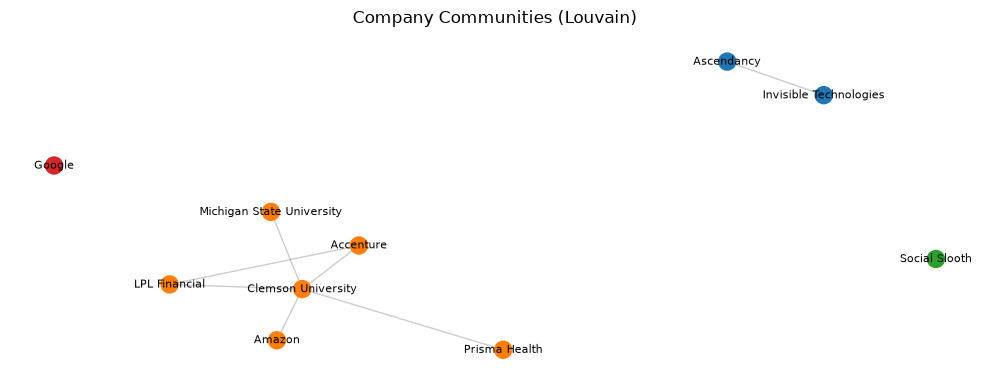

In [68]:
from networkx.algorithms import bipartite
from networkx.algorithms.community import louvain_communities

# get nodes of type company
company_nodes = [n for n, d in G.nodes(data=True) if d['type'] == 'company']

company_graph = bipartite.weighted_projected_graph(
    G,
    company_nodes
)

communities = louvain_communities(company_graph, weight="weight", seed=42)

# map each company -> community id
company_to_comm = {}
for i, comm in enumerate(communities):
    for node in comm:
        company_to_comm[node] = i

palette = plt.cm.tab10
node_colors = [palette(company_to_comm[n] % 10) for n in company_graph.nodes()]

plt.figure(figsize=(10, 4))
pos = nx.spring_layout(company_graph, seed=42, k=3, iterations=200)
nx.draw_networkx_edges(company_graph, pos, alpha=0.2)
nx.draw_networkx_nodes(company_graph, pos, node_size=150, node_color=node_colors)
nx.draw_networkx_labels(company_graph, pos, font_size=8)
plt.title("Company Communities (Louvain)")
plt.axis("off")
plt.tight_layout()
plt.show()